In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import zipfile

In [2]:
output_dir = Path("/mnt/data/taller_cv_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

In [3]:

h, w = 512, 512
img = np.full((h, w, 3), 220, dtype=np.uint8)


cv2.rectangle(img, (40, 60), (200, 200), (0, 255, 0), -1)
cv2.circle(img, (360, 140), 70, (0, 0, 255), -1)
pts = np.array([[260,320],[420,360],[320,440]], np.int32)
cv2.fillPoly(img, [pts], (255,0,0))


overlay = img.copy()
cv2.rectangle(overlay, (50,300),(230,480),(0,120,200), -1)
alpha = 0.5
cv2.addWeighted(overlay, alpha, img, 1-alpha, 0, img)


cv2.putText(img, "TEST 3D/IMG", (60, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (50,50,50), 2, cv2.LINE_AA)


orig_path = output_dir/"01_original.png"
cv2.imwrite(str(orig_path), img)


True

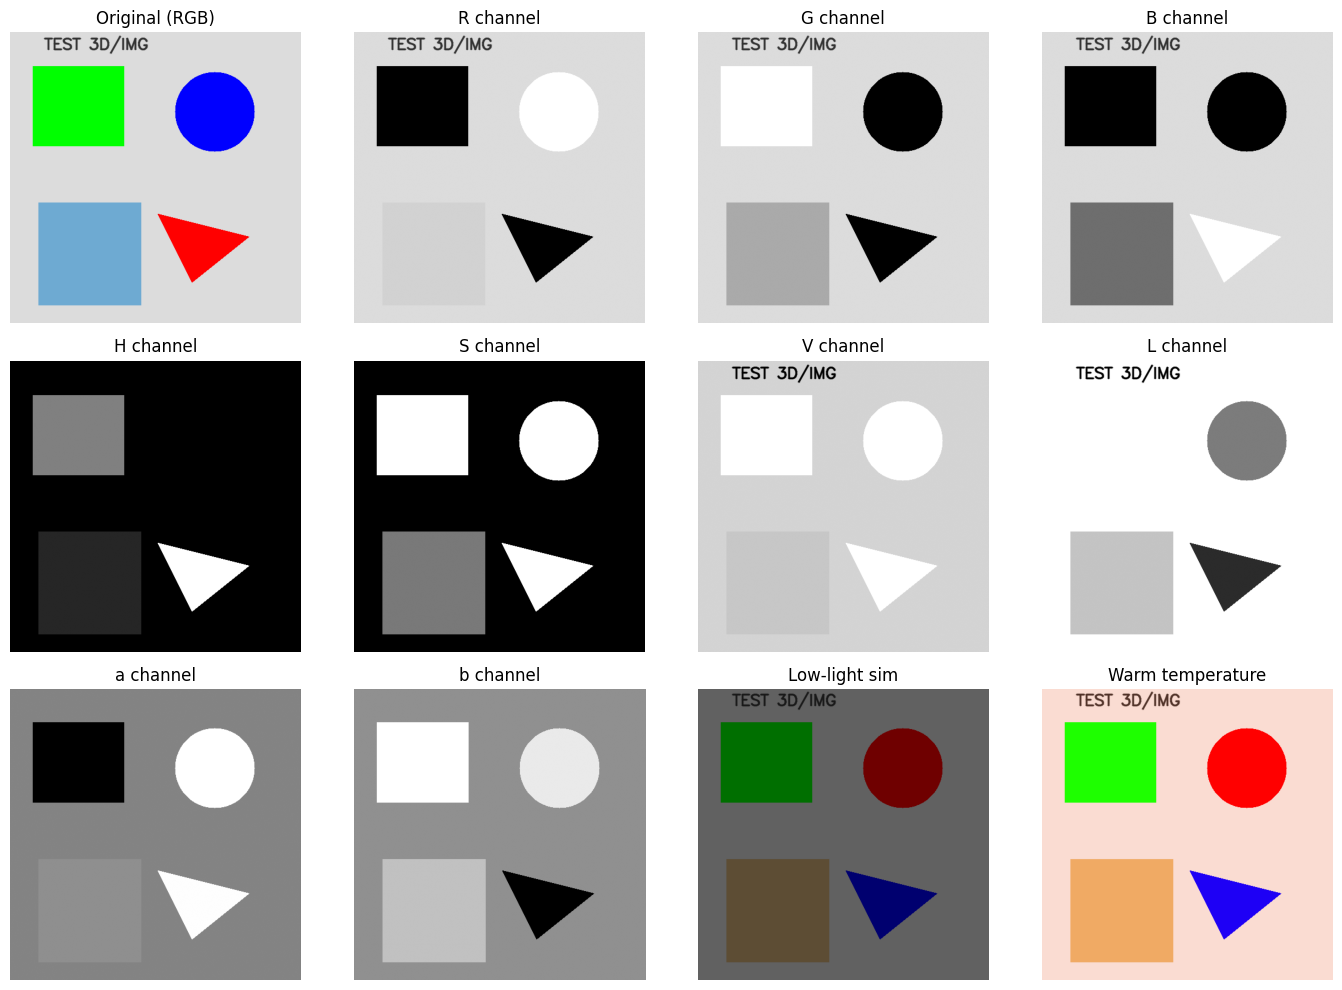

In [4]:
# -------------------------
# Ejercicio 10 - Explorando el Color
# -------------------------
def exercise_10(image):
    results = {}

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    results['hsv'] = hsv
    results['lab'] = lab

    b,g,r = cv2.split(image)
    h,s,v = cv2.split(hsv)
    l,a,b2 = cv2.split(lab)
    results['rgb_channels'] = (r,g,b)
    results['hsv_channels'] = (h,s,v)
    results['lab_channels'] = (l,a,b2)

    prot = np.array([[0.567, 0.433, 0.0],
                     [0.558, 0.442, 0.0],
                     [0.0,   0.242, 0.758]])
    deut = np.array([[0.625, 0.375, 0.0],
                     [0.7,   0.3,   0.0],
                     [0.0,   0.3,   0.7]])
    img_f = image.astype(np.float32)/255.0
    prot_img = np.clip(np.tensordot(img_f, prot.T, axes=([2],[0])), 0,1)
    deut_img = np.clip(np.tensordot(img_f, deut.T, axes=([2],[0])), 0,1)

    prot_bgr = (prot_img*255).astype(np.uint8)
    deut_bgr = (deut_img*255).astype(np.uint8)
    results['protanopia'] = prot_bgr
    results['deuteranopia'] = deut_bgr

    low = (img_f * 0.4) ** 0.9
    low_bgr = np.clip(low*255,0,255).astype(np.uint8)
    results['low_light'] = low_bgr

    temp_warm = image.copy().astype(np.int16)
    temp_warm[...,2] = np.clip(temp_warm[...,2] + 30, 0,255)
    temp_warm[...,0] = np.clip(temp_warm[...,0] - 10, 0,255)
    results['temp_warm'] = temp_warm.astype(np.uint8)
    return results

res10 = exercise_10(img)


fig3, axes3 = plt.subplots(3,4, figsize=(14,10))
axes3 = axes3.ravel()
plot_items = [
    (cv2.cvtColor(img, cv2.COLOR_BGR2RGB), "Original (RGB)"),
    (res10['rgb_channels'][0], "R channel"),
    (res10['rgb_channels'][1], "G channel"),
    (res10['rgb_channels'][2], "B channel"),
    (res10['hsv_channels'][0], "H channel"),
    (res10['hsv_channels'][1], "S channel"),
    (res10['hsv_channels'][2], "V channel"),
    (res10['lab_channels'][0], "L channel"),
    (res10['lab_channels'][1], "a channel"),
    (res10['lab_channels'][2], "b channel"),
    (res10['protanopia'], "Simulated Protanopia"),
    (res10['deuteranopia'], "Simulated Deuteranopia"),
]
for ax, (im, title) in zip(axes3, plot_items):
    if im.ndim==2:
        ax.imshow(im, cmap='gray')
    else:
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')

# last two slots: low_light and temp_warm
axes3[-2].imshow(cv2.cvtColor(res10['low_light'], cv2.COLOR_BGR2RGB)); axes3[-2].set_title("Low-light sim"); axes3[-2].axis('off')
axes3[-1].imshow(cv2.cvtColor(res10['temp_warm'], cv2.COLOR_BGR2RGB)); axes3[-1].set_title("Warm temperature"); axes3[-1].axis('off')

plt.tight_layout()
ex10_path = output_dir/"exercise_10_results.png"
plt.savefig(str(ex10_path), dpi=150)
plt.show()
